## Exercise 1 — Rotation Curves Produced by Different Mass Distributions

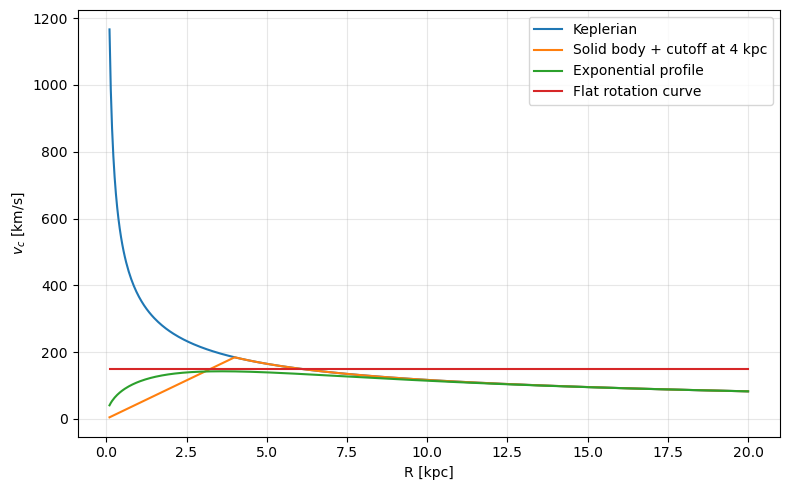

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 4.302e-6  # kpc (km/s)^2 / Msun
Mtot = 10**10.5  # Msun
Rd = 2.0  # kpc
Rmax_solid = 4.0  # kpc

# Radius grid
R = np.linspace(0.1, 20, 500)  # avoid R=0

# 1) Keplerian
v_kepler = np.sqrt(G * Mtot / R)

# 2) Solid-body with finite radius 4 kpc
rho0 = Mtot / ((4/3) * np.pi * Rmax_solid**3)
M_solid = np.where(R <= Rmax_solid,
                   (4/3) * np.pi * rho0 * R**3,
                   Mtot)
v_solid = np.sqrt(G * M_solid / R)

# 3) Exponential enclosed mass
M_exp = Mtot * (1 - np.exp(-R/Rd) * (1 + R/Rd))
v_exp = np.sqrt(G * M_exp / R)

# 4) Flat rotation curve
# choose normalization so it is easy to compare
V0 = 150.0  # km/s
v_flat = np.full_like(R, V0)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(R, v_kepler, label='Keplerian')
plt.plot(R, v_solid, label='Solid body + cutoff at 4 kpc')
plt.plot(R, v_exp, label='Exponential profile')
plt.plot(R, v_flat, label='Flat rotation curve')
plt.xlabel('R [kpc]')
plt.ylabel(r'$v_c$ [km/s]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercise 2 — Galaxy Kinematics: Mapping Velocity Fields

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# constants
G = 4.302e-6  # kpc (km/s)^2 / Msun
Mtot = 10**10.5  # Msun

# geometry
i = np.radians(45)  # inclination
Rd = 2.0  # kpc

# grid
x = np.linspace(-10,10,200)
y = np.linspace(-10,10,200)

xsky, ysky = np.meshgrid(x,y)

# convert to galaxy plane
xgal = xsky
ygal = ysky / np.cos(i)

# radius in galaxy plane
R = np.sqrt(xgal**2 + ygal**2) + 1e-6

# azimuth
costheta = xgal / R

### 2.1 Solid Body Rotation

For a constant density distribution (ρ = const), the enclosed mass grows as

M(R) ∝ R³

Using the circular velocity relation

v_c(R) = √(GM(R)/R)

we obtain

v_c(R) ∝ R

This corresponds to **solid body rotation**, where velocity increases linearly with radius.

The observed line-of-sight velocity is

v_los = v_c(R) cos(θ) sin(i)

which produces a characteristic velocity gradient across the galaxy.

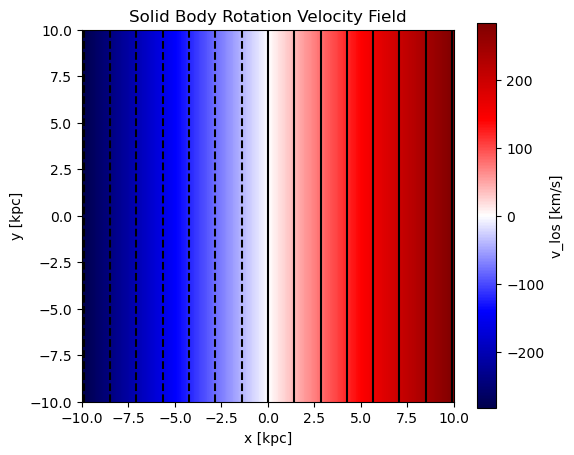

In [3]:
# solid body rotation
v0 = 40  # scaling factor
vc = v0 * R

vlos = vc * costheta * np.sin(i)

plt.figure(figsize=(6,5))
plt.imshow(vlos, origin='lower', extent=[-10,10,-10,10], cmap='seismic')
plt.colorbar(label='v_los [km/s]')
plt.contour(xsky, ysky, vlos, colors='k', levels=15)
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.title("Solid Body Rotation Velocity Field")
plt.show()

### 2.2 Flat Rotation Curve

Many observed galaxies exhibit flat rotation curves where

v_c(R) ≈ constant.

This implies that the enclosed mass grows linearly with radius

M(R) ∝ R

corresponding to a density profile

ρ(R) ∝ R⁻².

The projected velocity field is again given by

v_los = v_c cos(θ) sin(i).

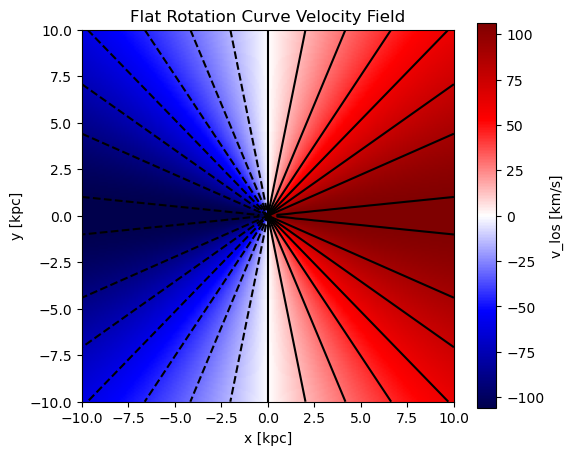

In [4]:
# flat rotation curve
vc = np.full_like(R,150)  # constant velocity

vlos = vc * costheta * np.sin(i)

plt.figure(figsize=(6,5))
plt.imshow(vlos, origin='lower', extent=[-10,10,-10,10], cmap='seismic')
plt.colorbar(label='v_los [km/s]')
plt.contour(xsky, ysky, vlos, colors='k', levels=15)
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.title("Flat Rotation Curve Velocity Field")
plt.show()

### 2.3 Exponential Mass Profile

Disk galaxies often follow an exponential surface density distribution

Σ(R) = Σ₀ e^{-R/R_d}

with scale radius Rd.

The enclosed mass profile is

M(R) = M_total [1 − e^{-R/R_d}(1 + R/R_d)]

which produces a rotation curve that rises rapidly in the inner region,
reaches a maximum, and then slowly declines.

This behaviour should produce **closed isovelocity contours** in the inner
regions where the velocity increases with radius.

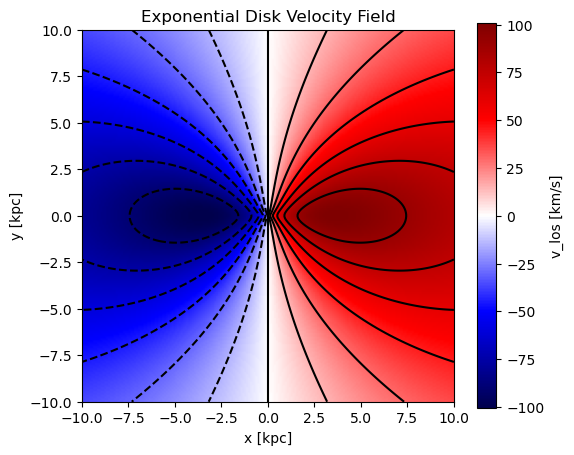

In [5]:
# exponential profile
Mexp = Mtot * (1 - np.exp(-R/Rd)*(1 + R/Rd))
vc = np.sqrt(G * Mexp / R)

vlos = vc * costheta * np.sin(i)

plt.figure(figsize=(6,5))
plt.imshow(vlos, origin='lower', extent=[-10,10,-10,10], cmap='seismic')
plt.colorbar(label='v_los [km/s]')
plt.contour(xsky, ysky, vlos, colors='k', levels=15)
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.title("Exponential Disk Velocity Field")
plt.show()

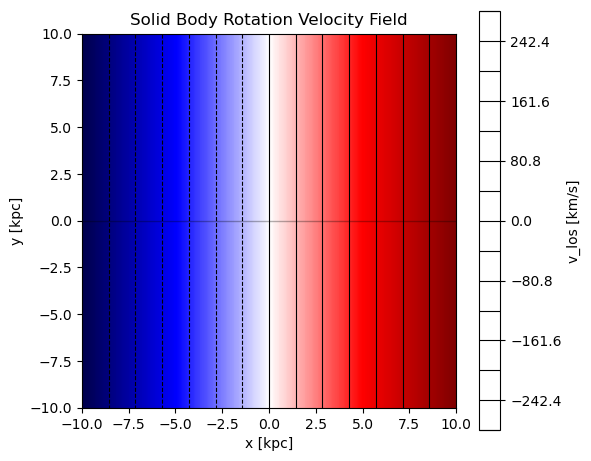

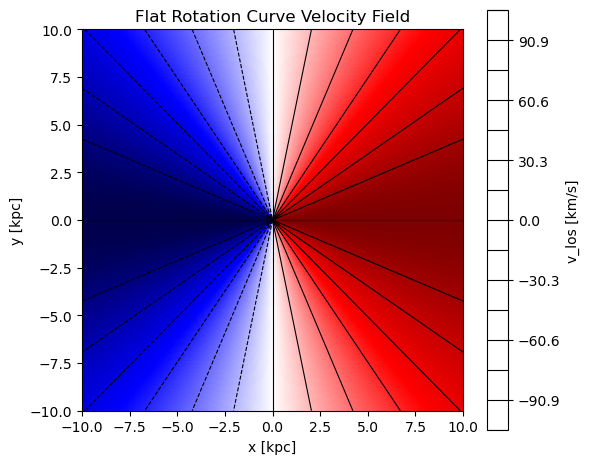

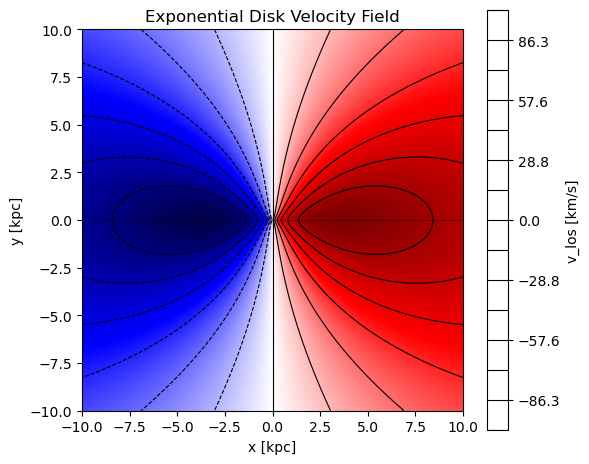

In [7]:
# 2.1 Solid Body Rotation

vc = 40 * R
vlos = vc * costheta * np.sin(i)

vmax = np.max(np.abs(vlos))
levels = np.linspace(-vmax, vmax, 15)

plt.figure(figsize=(6,5))
plt.imshow(
    vlos,
    origin='lower',
    extent=[-10,10,-10,10],
    cmap='seismic',
    vmin=-vmax,
    vmax=vmax
)
plt.contour(
    xsky, ysky, vlos,
    levels=levels,
    colors='k',
    linewidths=0.8
)
plt.axhline(0, color='k', lw=1, alpha=0.3)
plt.colorbar(label='v_los [km/s]')
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.title("Solid Body Rotation Velocity Field")
plt.tight_layout()
plt.show()

# 2.2 Flat Rotation Curve

vc = np.full_like(R, 150.0)
vlos = vc * costheta * np.sin(i)

vmax = np.max(np.abs(vlos))
levels = np.linspace(-vmax, vmax, 15)

plt.figure(figsize=(6,5))
plt.imshow(
    vlos,
    origin='lower',
    extent=[-10,10,-10,10],
    cmap='seismic',
    vmin=-vmax,
    vmax=vmax
)
plt.contour(
    xsky, ysky, vlos,
    levels=levels,
    colors='k',
    linewidths=0.8
)
plt.axhline(0, color='k', lw=1, alpha=0.3)
plt.colorbar(label='v_los [km/s]')
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.title("Flat Rotation Curve Velocity Field")
plt.tight_layout()
plt.show()

# 2.3 Exponential Profile

Mexp = Mtot * (1 - np.exp(-R/Rd) * (1 + R/Rd))
vc = np.sqrt(G * Mexp / R)
vlos = vc * costheta * np.sin(i)

vmax = np.max(np.abs(vlos))
levels = np.linspace(-vmax, vmax, 15)

plt.figure(figsize=(6,5))
plt.imshow(
    vlos,
    origin='lower',
    extent=[-10,10,-10,10],
    cmap='seismic',
    vmin=-vmax,
    vmax=vmax
)
plt.contour(
    xsky, ysky, vlos,
    levels=levels,
    colors='k',
    linewidths=0.8
)
plt.axhline(0, color='k', lw=1, alpha=0.3)
plt.colorbar(label='v_los [km/s]')
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.title("Exponential Disk Velocity Field")
plt.tight_layout()
plt.show()

## Exercise 3 — Deriving Rotation Curves from Kinematic Data

### 3.1 Redshift of NGC 3198

We first compute the redshift of NGC 3198 from its systemic velocity,

\[
z \approx \frac{v_{\rm sys}}{c}
\]

using the non-relativistic approximation. We then check whether a relativistic correction is necessary.

In [8]:
import numpy as np

# constants
c_kms = 299792.458  # km/s
vsys = 660.7        # km/s

z = vsys / c_kms
print(f"Redshift z = {z:.6f}")

# relativistic check
beta = vsys / c_kms
z_rel = np.sqrt((1 + beta) / (1 - beta)) - 1
print(f"Relativistic redshift = {z_rel:.6f}")
print(f"Difference = {abs(z_rel - z):.2e}")

Redshift z = 0.002204
Relativistic redshift = 0.002206
Difference = 2.43e-06


### 3.2 HI velocity field and isovelocity contours

We now load the THINGS HI moment-1 velocity map of NGC 3198. The observed velocity field contains both the systemic velocity and the rotational component,

\[
v_{\rm obs} = v_{\rm los} + v_{\rm sys}
\]

so we subtract \(v_{\rm sys}\) to isolate the line-of-sight rotational velocity \(v_{\rm los}\). We then plot the 2D velocity field and overplot isovelocity contours.

Shape after squeeze: (1024, 1024)


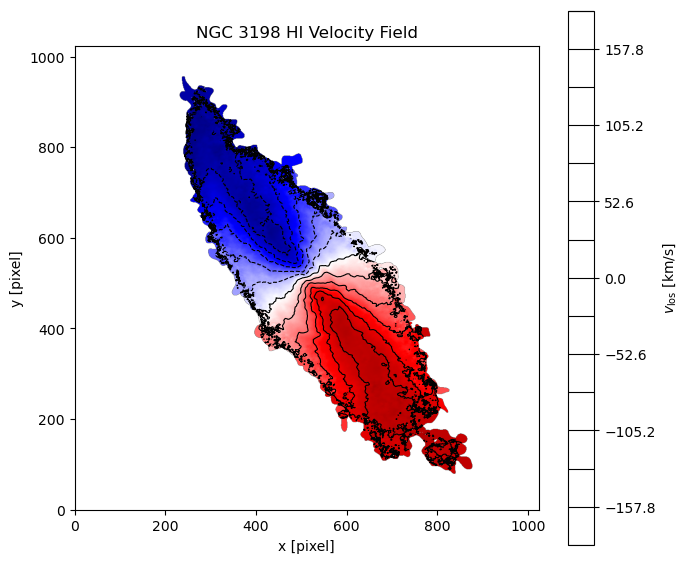

In [10]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

fits_path = "NGC_3198_NA_MOM1_THINGS.FITS"

hdu = fits.open(fits_path)
vel_2d = np.squeeze(hdu[0].data)   # remove extra dimensions
header = hdu[0].header

print("Shape after squeeze:", vel_2d.shape)

# FITS units are m/s, convert to km/s
vel_2d = vel_2d / 1000.0

# subtract systemic velocity
vlos_map = vel_2d - vsys

# clean invalid values
vlos_plot = np.array(vlos_map, dtype=float)
vlos_plot[~np.isfinite(vlos_plot)] = np.nan

vmax = np.nanmax(np.abs(vlos_plot))
levels = np.linspace(-vmax, vmax, 15)

ny, nx = vlos_plot.shape
extent = [0, nx, 0, ny]

plt.figure(figsize=(7,6))
plt.imshow(
    vlos_plot,
    origin="lower",
    cmap="seismic",
    vmin=-vmax,
    vmax=vmax,
    extent=extent
)
plt.contour(
    vlos_plot,
    levels=levels,
    colors="k",
    linewidths=0.8,
    origin="lower",
    extent=extent
)
plt.colorbar(label=r"$v_{\rm los}$ [km/s]")
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.title("NGC 3198 HI Velocity Field")
plt.tight_layout()
plt.show()

### 3.3 Extracting and folding the rotation curve

We extract the velocity along the major axis using a 5-pixel wide slit. The line-of-sight velocity is then corrected for inclination:

\[
v_c(R) = \frac{|v_{\rm los}|}{\sin i}
\]

We convert pixel offsets into physical radii using the pixel scale of 1.5 arcsec/pixel and the angular diameter distance at the redshift of NGC 3198. Finally, we fold the approaching and receding sides together and compute the median rotation curve with scatter-based uncertainties.

kpc per pixel = 0.1004
Using center = (512, 513)
Image angle = 305.00 deg


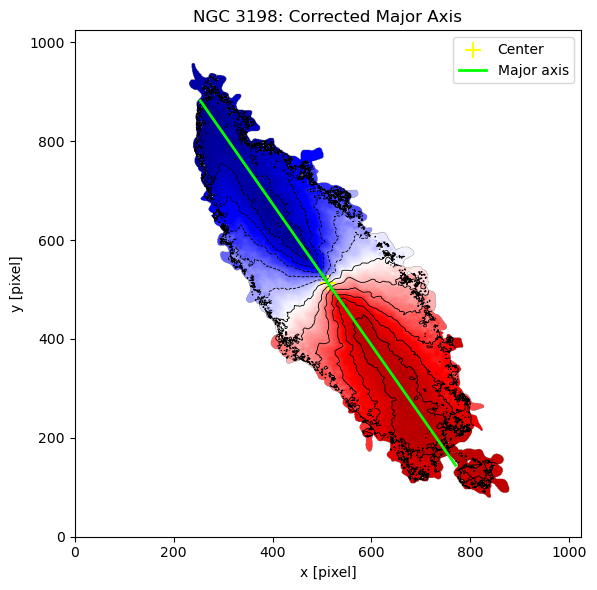

Number of slit pixels used: 4752


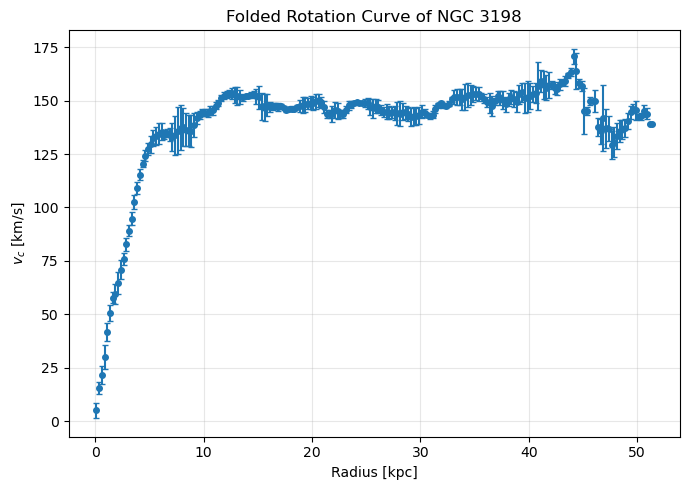

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# galaxy parameters
incl_deg = 71.5
incl = np.radians(incl_deg)

PA_deg = 215.0   # from de Blok et al.
# convert sky PA to image angle:
# PA is measured from north through east,
# but image x-axis increases to the right while RA increases to the left
theta_img = np.radians(90 + PA_deg)

# center
xc, yc = 512, 513

# use literature distance, not redshift distance
D_Mpc = 13.8
pixel_scale_arcsec = 1.5

kpc_per_pixel = D_Mpc * 1000 * np.deg2rad(pixel_scale_arcsec / 3600)
print(f"kpc per pixel = {kpc_per_pixel:.4f}")
print(f"Using center = ({xc}, {yc})")
print(f"Image angle = {np.degrees(theta_img):.2f} deg")

plt.figure(figsize=(7,6))
plt.imshow(vlos_plot, origin="lower", cmap="seismic", vmin=-vmax, vmax=vmax)
plt.contour(vlos_plot, levels=levels, colors="k", linewidths=0.6, origin="lower")

plt.scatter([xc], [yc], color="yellow", marker="+", s=120, label="Center")

length = 450
dx = length * np.cos(theta_img)
dy = length * np.sin(theta_img)

plt.plot([xc - dx, xc + dx], [yc - dy, yc + dy], color="lime", lw=2, label="Major axis")

plt.xlim(0, 1024)
plt.ylim(0, 1024)
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.title("NGC 3198: Corrected Major Axis")
plt.legend()
plt.tight_layout()
plt.show()

yy, xx = np.indices(vlos_plot.shape)

xrel = xx - xc
yrel = yy - yc

# rotate into major/minor-axis coordinates
x_major = xrel * np.cos(theta_img) + yrel * np.sin(theta_img)
y_minor = -xrel * np.sin(theta_img) + yrel * np.cos(theta_img)

# 5-pixel-wide slit
half_width = 2.5
slit_mask = np.abs(y_minor) <= half_width

R_pix_signed = x_major[slit_mask]
V_los = vlos_plot[slit_mask]

valid = np.isfinite(V_los)
R_pix_signed = R_pix_signed[valid]
V_los = V_los[valid]

print(f"Number of slit pixels used: {len(V_los)}")

Vc = np.abs(V_los) / np.sin(incl)
R_kpc = np.abs(R_pix_signed) * kpc_per_pixel

bins = np.arange(0, np.nanmax(R_kpc) + 0.25, 0.25)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

vc_med = []
vc_err = []
n_per_bin = []

for r1, r2 in zip(bins[:-1], bins[1:]):
    m = (R_kpc >= r1) & (R_kpc < r2)
    vals = Vc[m]
    vals = vals[np.isfinite(vals)]
    
    if len(vals) >= 5:
        vc_med.append(np.median(vals))
        vc_err.append(np.std(vals))
        n_per_bin.append(len(vals))
    else:
        vc_med.append(np.nan)
        vc_err.append(np.nan)
        n_per_bin.append(0)

vc_med = np.array(vc_med)
vc_err = np.array(vc_err)
n_per_bin = np.array(n_per_bin)

plt.figure(figsize=(7,5))
plt.errorbar(bin_centers, vc_med, yerr=vc_err, fmt='o', ms=4, capsize=2)
plt.xlabel("Radius [kpc]")
plt.ylabel(r"$v_c$ [km/s]")
plt.title("Folded Rotation Curve of NGC 3198")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Stellar contribution from an exponential disk

The stellar disk is modeled using the Freeman (1970) thin exponential disk solution,

\[
v_{\star}^2(R)=4\pi G \Sigma_0 R_d y^2 [I_0(y)K_0(y)-I_1(y)K_1(y)]
\]

where

\[
y = \frac{R}{2R_d}, \qquad \Sigma_0 = \frac{M_\star}{2\pi R_d^2}.
\]

We use the stellar mass and scale radius provided for NGC 3198.

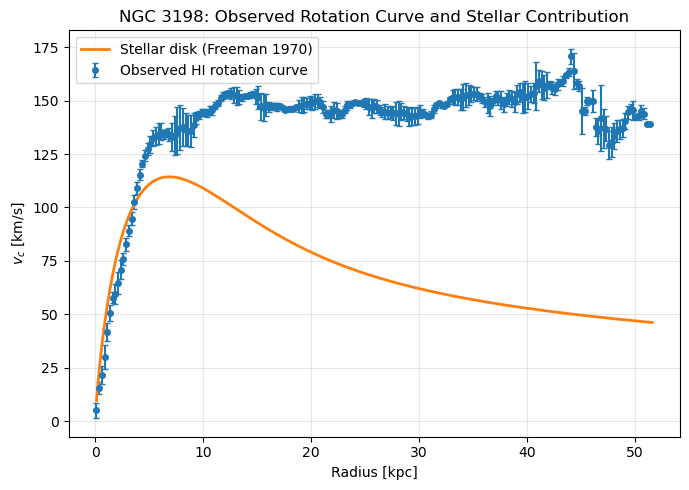

In [13]:
from scipy.special import iv, kv
import numpy as np
import matplotlib.pyplot as plt

# stellar disk parameters
Rd_star = 3.2          # kpc
Mstar = 10**10.4       # Msun

# central surface density
Sigma0 = Mstar / (2 * np.pi * Rd_star**2)

# use the same radius grid as the observed folded curve
R_model = bin_centers.copy()
R_model[R_model == 0] = 1e-3  # avoid y=0 issues

y = R_model / (2 * Rd_star)

# Freeman disk formula
vstar2 = 4 * np.pi * G * Sigma0 * Rd_star * y**2 * (
    iv(0, y) * kv(0, y) - iv(1, y) * kv(1, y)
)

vstar = np.sqrt(np.maximum(vstar2, 0))

# plot
plt.figure(figsize=(7,5))
plt.errorbar(
    bin_centers, vc_med, yerr=vc_err,
    fmt='o', ms=4, capsize=2, label="Observed HI rotation curve"
)
plt.plot(R_model, vstar, lw=2, label="Stellar disk (Freeman 1970)")
plt.xlabel("Radius [kpc]")
plt.ylabel(r"$v_c$ [km/s]")
plt.title("NGC 3198: Observed Rotation Curve and Stellar Contribution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 Adding the gas component

We now include the gaseous contribution using the provided rotation-model data file. The total baryonic contribution is

\[
v_{\rm bar}(R) = \sqrt{v_{\star}^2(R) + v_{\rm gas}^2(R)}.
\]

We compare this with the observed rotation curve to assess whether visible matter alone explains the dynamics.

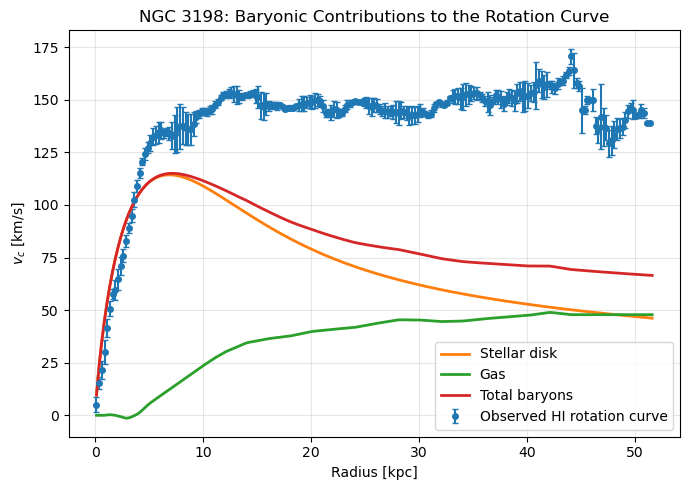

In [14]:
# load rotation model file
rotmod = np.loadtxt("NGC3198_rotmod.dat")

R_gas = rotmod[:,0]     # kpc
V_gas = rotmod[:,3]     # gas contribution

# interpolate gas curve to our radius grid
Vgas_interp = np.interp(R_model, R_gas, V_gas)

# total baryonic rotation curve
Vbar = np.sqrt(vstar**2 + Vgas_interp**2)

# plot comparison
plt.figure(figsize=(7,5))

plt.errorbar(
    bin_centers, vc_med, yerr=vc_err,
    fmt='o', ms=4, capsize=2,
    label="Observed HI rotation curve"
)

plt.plot(R_model, vstar, lw=2, label="Stellar disk")
plt.plot(R_model, Vgas_interp, lw=2, label="Gas")
plt.plot(R_model, Vbar, lw=2, label="Total baryons")

plt.xlabel("Radius [kpc]")
plt.ylabel(r"$v_c$ [km/s]")
plt.title("NGC 3198: Baryonic Contributions to the Rotation Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Dark matter fraction

We quantify the dark matter contribution using

\[
f_{\rm DM}(R)=1-\left(\frac{v_{\rm bar}}{v_c}\right)^2.
\]

We evaluate this at \(1R_d\), \(3R_d\), and \(5R_d\), where \(R_d=3.2\) kpc.

1 Rd = 3.20 kpc:  vc = 90.78 km/s,  vbar = 96.85 km/s,  fDM = -0.138
3 Rd = 9.60 kpc:  vc = 143.18 km/s,  vbar = 112.29 km/s,  fDM = 0.385
5 Rd = 16.00 kpc:  vc = 147.34 km/s,  vbar = 96.98 km/s,  fDM = 0.567


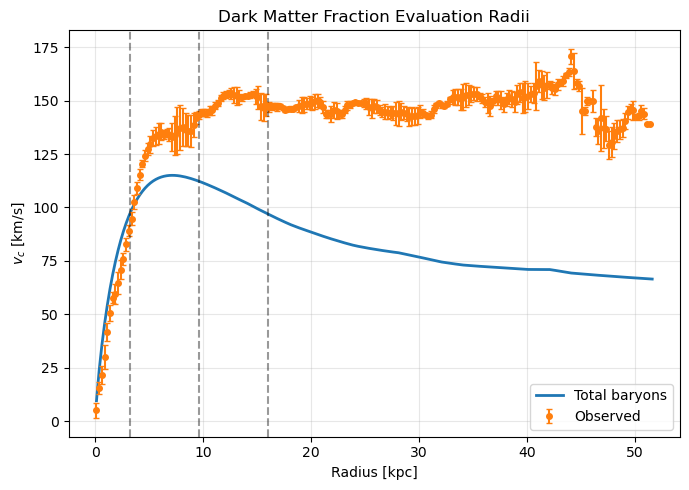

In [15]:
# 3.6 Dark matter fraction

Rd_eval = 3.2
r_eval = np.array([1, 3, 5]) * Rd_eval   # kpc

# use only valid observed points for interpolation
valid_obs = np.isfinite(vc_med)
R_obs_valid = bin_centers[valid_obs]
Vc_valid = vc_med[valid_obs]

# interpolate observed and baryonic curves at the chosen radii
Vc_eval = np.interp(r_eval, R_obs_valid, Vc_valid)
Vbar_eval = np.interp(r_eval, R_model, Vbar)

fDM = 1 - (Vbar_eval / Vc_eval)**2

for n, r, vc_i, vb_i, f_i in zip([1, 3, 5], r_eval, Vc_eval, Vbar_eval, fDM):
    print(f"{n} Rd = {r:.2f} kpc:  vc = {vc_i:.2f} km/s,  vbar = {vb_i:.2f} km/s,  fDM = {f_i:.3f}")
    
plt.figure(figsize=(7,5))
plt.plot(R_model, Vbar, lw=2, label="Total baryons")
plt.errorbar(bin_centers, vc_med, yerr=vc_err, fmt='o', ms=4, capsize=2, label="Observed")
for r in r_eval:
    plt.axvline(r, color='k', ls='--', alpha=0.4)
plt.xlabel("Radius [kpc]")
plt.ylabel(r"$v_c$ [km/s]")
plt.title("Dark Matter Fraction Evaluation Radii")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Exercise 4 — Dynamical Constraints on Dark Matter Distributions

### 4.1 NGC 3198: extract the dark matter rotation curve

The observed circular velocity can be decomposed into stellar, gas, and dark matter components:

\[
v_c^2(R)=v_\star^2(R)+v_{\rm gas}^2(R)+v_{\rm DM}^2(R)
\]

Using the observed rotation curve from Exercise 3 and the baryonic contribution

\[
v_{\rm bar}^2=v_\star^2+v_{\rm gas}^2,
\]

we derive the dark matter rotation curve as

\[
v_{\rm DM}(R)=\sqrt{v_c^2-v_{\rm bar}^2}.
\]

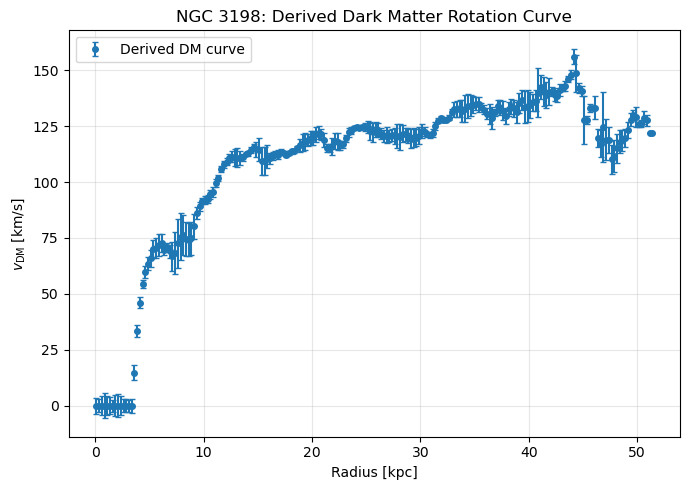

In [16]:
# 4.1 dark matter rotation curve for NGC 3198

# valid observed points
valid_obs = np.isfinite(vc_med) & np.isfinite(vc_err)
R_fit = bin_centers[valid_obs]
Vc_fit = vc_med[valid_obs]
Vc_err_fit = vc_err[valid_obs]

# interpolate baryons onto observed radii
Vbar_fit = np.interp(R_fit, R_model, Vbar)

# avoid negative values from numerical noise
Vdm2 = np.maximum(Vc_fit**2 - Vbar_fit**2, 0)
Vdm_fit = np.sqrt(Vdm2)

plt.figure(figsize=(7,5))
plt.errorbar(R_fit, Vdm_fit, yerr=Vc_err_fit, fmt='o', ms=4, capsize=2, label="Derived DM curve")
plt.xlabel("Radius [kpc]")
plt.ylabel(r"$v_{\rm DM}$ [km/s]")
plt.title("NGC 3198: Derived Dark Matter Rotation Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Fit an NFW halo to NGC 3198

We fit the derived dark matter rotation curve with an NFW halo. The model is parameterized by the virial mass \(M_{200}\) and concentration \(c\), with

\[
r_{200}=\left(\frac{3M_{200}}{4\pi\,200\,\rho_c}\right)^{1/3}
\]

and

\[
v_{\rm DM}(r)=v_{200}
\sqrt{
\frac{\ln(1+cx)-cx/(1+cx)}
{x[\ln(1+c)-c/(1+c)]}
}
\]

where \(x=r/r_{200}\).

Number of fitted points: 189
Min/Max radius: 3.625 50.875
Min/Max error: 0.544882448780222 15.438787643827649
NFW fit: logM200 = 11.837
M200 = 6.873e+11 Msun
c = 5.50
Reduced chi^2 = 9.932


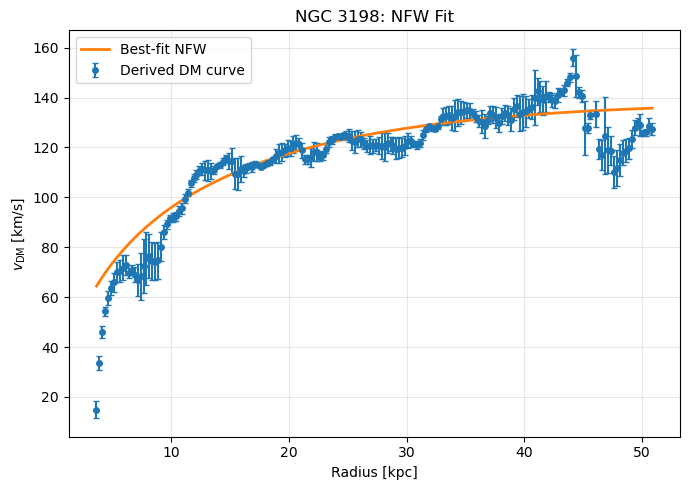

In [18]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# constants
G = 4.302e-6   # kpc (km/s)^2 / Msun
H0_kpc = 70 / 1000.0  # km/s/kpc
rho_crit = 3 * H0_kpc**2 / (8 * np.pi * G)  # Msun/kpc^3

def r200_from_M200(M200):
    return ((3 * M200) / (4 * np.pi * 200 * rho_crit))**(1/3)

def v200_from_M200_r200(M200, r200):
    return np.sqrt(G * M200 / r200)

def v_nfw(r, logM200, c):
    M200 = 10**logM200
    r200 = r200_from_M200(M200)
    v200 = v200_from_M200_r200(M200, r200)
    x = r / r200

    f_c = np.log(1 + c) - c / (1 + c)
    num = np.log(1 + c*x) - (c*x) / (1 + c*x)
    den = x * f_c

    val = v200 * np.sqrt(num / den)
    return val

# cleaner fitting mask
mask = (
    np.isfinite(Vdm_fit) &
    np.isfinite(Vc_err_fit) &
    (Vc_err_fit > 0) &
    (Vdm_fit > 5) &        # avoid zero/near-zero DM points
    (R_fit > 2.0)          # exclude unstable innermost region
)

R_nfw = R_fit[mask]
V_nfw_data = Vdm_fit[mask]
V_nfw_err = Vc_err_fit[mask]

print("Number of fitted points:", len(R_nfw))
print("Min/Max radius:", R_nfw.min(), R_nfw.max())
print("Min/Max error:", V_nfw_err.min(), V_nfw_err.max())

# initial guess and bounds
p0 = [11.5, 10.0]              # logM200, c
bounds = ([9.5, 1.0], [13.5, 40.0])

popt_nfw, pcov_nfw = curve_fit(
    v_nfw,
    R_nfw,
    V_nfw_data,
    sigma=V_nfw_err,
    absolute_sigma=True,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

logM200_nfw, c_nfw = popt_nfw
M200_nfw = 10**logM200_nfw

model_nfw = v_nfw(R_nfw, *popt_nfw)

chi2_nfw = np.sum(((V_nfw_data - model_nfw) / V_nfw_err)**2)
dof_nfw = len(R_nfw) - len(popt_nfw)
chi2red_nfw = chi2_nfw / dof_nfw

print(f"NFW fit: logM200 = {logM200_nfw:.3f}")
print(f"M200 = {M200_nfw:.3e} Msun")
print(f"c = {c_nfw:.2f}")
print(f"Reduced chi^2 = {chi2red_nfw:.3f}")

plt.figure(figsize=(7,5))
plt.errorbar(R_nfw, V_nfw_data, yerr=V_nfw_err, fmt='o', ms=4, capsize=2, label="Derived DM curve")
plt.plot(R_nfw, model_nfw, lw=2, label="Best-fit NFW")
plt.xlabel("Radius [kpc]")
plt.ylabel(r"$v_{\rm DM}$ [km/s]")
plt.title("NGC 3198: NFW Fit")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Fit a Burkert halo to NGC 3198

We now fit the derived dark matter rotation curve with a Burkert profile, which describes a cored dark matter halo:

\[
\rho(r)=\frac{\rho_0}{(1+r/r_0)(1+(r/r_0)^2)}.
\]

The enclosed mass is

\[
M(r)=\pi \rho_0 r_0^3
\left[
\ln\left(1+\left(\frac{r}{r_0}\right)^2\right)
+2\ln\left(1+\frac{r}{r_0}\right)
-2\arctan\left(\frac{r}{r_0}\right)
\right]
\]

and the circular velocity is

\[
v(r)=\sqrt{\frac{GM(r)}{r}}.
\]

This profile is expected to better describe halos with a constant-density core.

Burkert fit: log rho0 = 7.019
rho0 = 1.044e+07 Msun/kpc^3
r0 = 11.78 kpc
Reduced chi^2 = 8.321


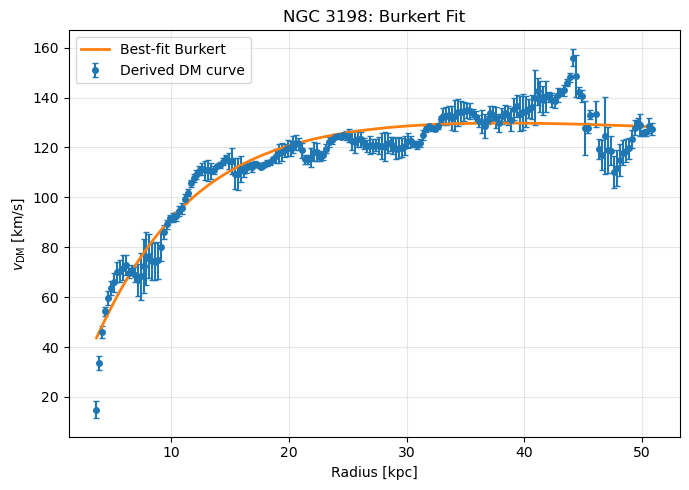

In [19]:
def burkert_mass(r, rho0, r0):
    x = r / r0
    term = np.log(1 + x**2) + 2*np.log(1 + x) - 2*np.arctan(x)
    return np.pi * rho0 * r0**3 * term

def v_burkert(r, logrho0, r0):
    rho0 = 10**logrho0
    M = burkert_mass(r, rho0, r0)
    return np.sqrt(G * M / r)

# use the same cleaned fitting sample as for NFW
R_bur = R_nfw.copy()
V_bur_data = V_nfw_data.copy()
V_bur_err = V_nfw_err.copy()

# initial guess and bounds
p0 = [7.0, 5.0]                 # logrho0, r0[kpc]
bounds = ([4.0, 0.1], [10.0, 50.0])

popt_bur, pcov_bur = curve_fit(
    v_burkert,
    R_bur,
    V_bur_data,
    sigma=V_bur_err,
    absolute_sigma=True,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

logrho0_bur, r0_bur = popt_bur
rho0_bur = 10**logrho0_bur

model_bur = v_burkert(R_bur, *popt_bur)

chi2_bur = np.sum(((V_bur_data - model_bur) / V_bur_err)**2)
dof_bur = len(R_bur) - len(popt_bur)
chi2red_bur = chi2_bur / dof_bur

print(f"Burkert fit: log rho0 = {logrho0_bur:.3f}")
print(f"rho0 = {rho0_bur:.3e} Msun/kpc^3")
print(f"r0 = {r0_bur:.2f} kpc")
print(f"Reduced chi^2 = {chi2red_bur:.3f}")

plt.figure(figsize=(7,5))
plt.errorbar(R_bur, V_bur_data, yerr=V_bur_err, fmt='o', ms=4, capsize=2, label="Derived DM curve")
plt.plot(R_bur, model_bur, lw=2, label="Best-fit Burkert")
plt.xlabel("Radius [kpc]")
plt.ylabel(r"$v_{\rm DM}$ [km/s]")
plt.title("NGC 3198: Burkert Fit")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

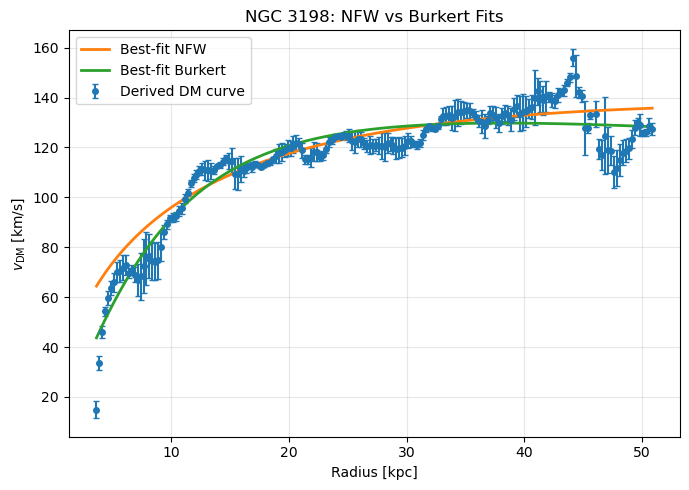

In [20]:
plt.figure(figsize=(7,5))
plt.errorbar(R_nfw, V_nfw_data, yerr=V_nfw_err, fmt='o', ms=4, capsize=2, label="Derived DM curve")
plt.plot(R_nfw, model_nfw, lw=2, label="Best-fit NFW")
plt.plot(R_bur, model_bur, lw=2, label="Best-fit Burkert")
plt.xlabel("Radius [kpc]")
plt.ylabel(r"$v_{\rm DM}$ [km/s]")
plt.title("NGC 3198: NFW vs Burkert Fits")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 Compare NFW and Burkert density profiles

We now compare the dark matter density profiles corresponding to the best-fit NFW and Burkert models. The NFW profile has a central cusp, while the Burkert profile has a constant-density core. Plotting both on a log-log scale allows us to directly identify where the two models diverge.

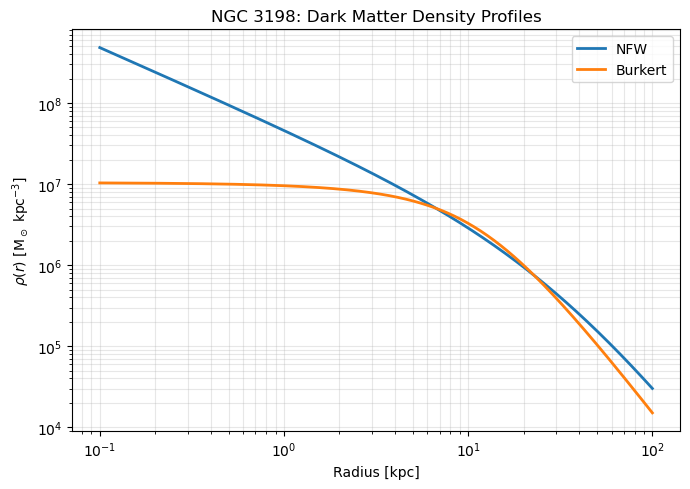

In [21]:
def rho_nfw(r, logM200, c):
    M200 = 10**logM200
    r200 = r200_from_M200(M200)
    rs = r200 / c
    f = np.log(1 + c) - c/(1 + c)
    rho_s = M200 / (4 * np.pi * rs**3 * f)
    x = r / rs
    return rho_s / (x * (1 + x)**2)

def rho_burkert(r, logrho0, r0):
    rho0 = 10**logrho0
    x = r / r0
    return rho0 / ((1 + x) * (1 + x**2))

rplot = np.logspace(-1, 2, 500)  # 0.1 to 100 kpc

rho_nfw_plot = rho_nfw(rplot, *popt_nfw)
rho_bur_plot = rho_burkert(rplot, *popt_bur)

plt.figure(figsize=(7,5))
plt.loglog(rplot, rho_nfw_plot, lw=2, label="NFW")
plt.loglog(rplot, rho_bur_plot, lw=2, label="Burkert")
plt.xlabel("Radius [kpc]")
plt.ylabel(r"$\rho(r)$ [M$_\odot$ kpc$^{-3}$]")
plt.title("NGC 3198: Dark Matter Density Profiles")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### 4.5 Fit NGC 0247 and NGC 3109

We now repeat the dark matter halo fitting for the spiral galaxy NGC 0247 and the dwarf galaxy NGC 3109 using the provided rotation-curve decomposition files. For each galaxy, we compute the dark matter rotation curve from

\[
v_{\rm DM}(R)=\sqrt{v_c^2-v_\star^2-v_{\rm gas}^2}
\]

and fit both NFW and Burkert halo models. The quality of the fits is compared using the reduced \(\chi^2\).

NGC0247 shape: (26, 8)
[[ 1.08 34.6   0.9   2.87 22.18  0.   66.02  0.  ]
 [ 1.61 47.    0.8   4.22 29.63  0.   54.33  0.  ]
 [ 2.15 59.1   3.1   5.53 34.54  0.   44.47  0.  ]
 [ 2.7  64.4   1.4   7.02 38.17  0.   37.92  0.  ]
 [ 3.22 67.4   2.3   8.74 41.49  0.   33.35  0.  ]]

NGC3109 shape: (25, 8)
[[ 0.26  6.1   1.6   1.    2.78  0.   10.55  0.  ]
 [ 0.52 11.2   0.7   2.12  4.73  0.    8.77  0.  ]
 [ 0.77 14.9   1.5   4.53  7.    0.    8.41  0.  ]
 [ 1.03 19.1   2.2   6.54  8.59  0.    7.93  0.  ]
 [ 1.29 24.3   0.9   8.22 10.63  0.    6.67  0.  ]]

NGC 0247
NFW:     logM200 = 11.410, c = 5.07, reduced chi2 = 2.750
Burkert: logrho0 = 7.573, r0 = 3.19, reduced chi2 = 6.507


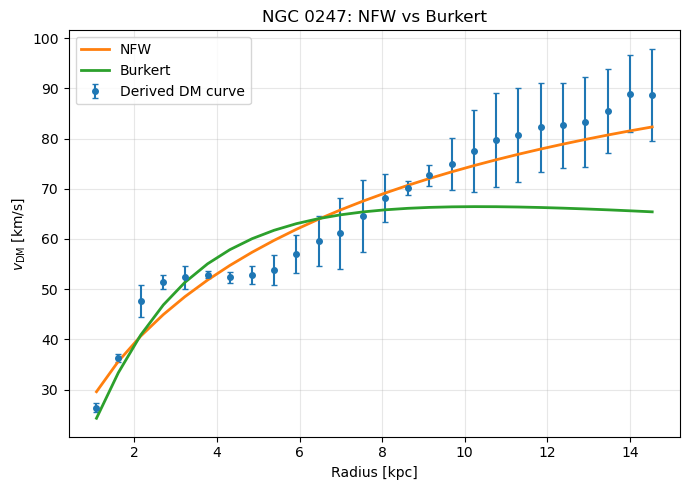


NGC 3109
NFW:     logM200 = 12.916, c = 1.00, reduced chi2 = 10.804
Burkert: logrho0 = 7.271, r0 = 5.12, reduced chi2 = 0.256


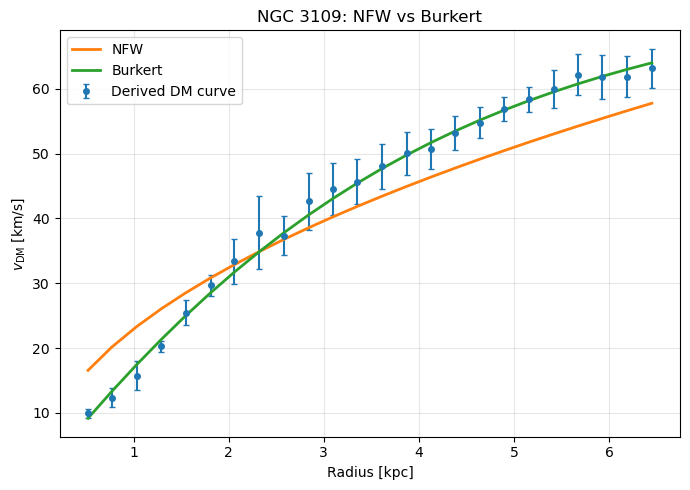

In [24]:
ngc247 = np.loadtxt("NGC0247_rotmod.dat")
ngc3109 = np.loadtxt("NGC3109_rotmod.dat")

print("NGC0247 shape:", ngc247.shape)
print(ngc247[:5])
print()
print("NGC3109 shape:", ngc3109.shape)
print(ngc3109[:5])

def fit_galaxy_dm(rotmod, name):
    R = rotmod[:, 0]
    Vobs = rotmod[:, 1]
    Verr = rotmod[:, 2]
    Vgas = rotmod[:, 3]
    Vdisk = rotmod[:, 4]
    Vbul = rotmod[:, 5]

    Vstar = np.sqrt(Vdisk**2 + Vbul**2)
    Vbar = np.sqrt(Vstar**2 + Vgas**2)
    Vdm = np.sqrt(np.maximum(Vobs**2 - Vbar**2, 0))

    mask = (
        np.isfinite(R) &
        np.isfinite(Vdm) &
        np.isfinite(Verr) &
        (Verr > 0) &
        (Vdm > 1) &
        (R > 0.3)
    )

    Rf = R[mask]
    Vdmf = Vdm[mask]
    Verrf = Verr[mask]

    popt_nfw, _ = curve_fit(
        v_nfw, Rf, Vdmf,
        sigma=Verrf, absolute_sigma=True,
        p0=[10.5, 10.0],
        bounds=([8.5, 1.0], [13.5, 40.0]),
        maxfev=20000
    )
    model_nfw = v_nfw(Rf, *popt_nfw)
    chi2red_nfw = np.sum(((Vdmf - model_nfw) / Verrf)**2) / (len(Rf) - 2)

    popt_bur, _ = curve_fit(
        v_burkert, Rf, Vdmf,
        sigma=Verrf, absolute_sigma=True,
        p0=[7.0, 3.0],
        bounds=([4.0, 0.1], [10.0, 50.0]),
        maxfev=20000
    )
    model_bur = v_burkert(Rf, *popt_bur)
    chi2red_bur = np.sum(((Vdmf - model_bur) / Verrf)**2) / (len(Rf) - 2)

    print(f"\n{name}")
    print(f"NFW:     logM200 = {popt_nfw[0]:.3f}, c = {popt_nfw[1]:.2f}, reduced chi2 = {chi2red_nfw:.3f}")
    print(f"Burkert: logrho0 = {popt_bur[0]:.3f}, r0 = {popt_bur[1]:.2f}, reduced chi2 = {chi2red_bur:.3f}")

    plt.figure(figsize=(7,5))
    plt.errorbar(Rf, Vdmf, yerr=Verrf, fmt='o', ms=4, capsize=2, label="Derived DM curve")
    plt.plot(Rf, model_nfw, lw=2, label="NFW")
    plt.plot(Rf, model_bur, lw=2, label="Burkert")
    plt.xlabel("Radius [kpc]")
    plt.ylabel(r"$v_{\rm DM}$ [km/s]")
    plt.title(f"{name}: NFW vs Burkert")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "R": Rf,
        "Vdm": Vdmf,
        "Vbar": Vbar,
        "popt_nfw": popt_nfw,
        "chi2red_nfw": chi2red_nfw,
        "popt_bur": popt_bur,
        "chi2red_bur": chi2red_bur
    }
    
fit247 = fit_galaxy_dm(ngc247, "NGC 0247")
fit3109 = fit_galaxy_dm(ngc3109, "NGC 3109")

### 4.6 Stellar-to-halo mass ratio and baryon fraction

We compute the stellar-to-halo mass ratio

\[
f_\*=\frac{M_\*}{M_{\rm DM}}
\]

and the baryon fraction

\[
f_b=\frac{M_\*+M_{\rm gas}}{M_{\rm DM}}.
\]

We compare the inferred baryon fractions with the cosmic baryon fraction \(f_b \approx 0.16\). If the galaxy baryon fraction is much smaller than the cosmic value, it implies that a large fraction of baryons are missing from the observed galaxy, likely due to inefficient gas retention and feedback processes.

In [25]:
# stellar and gas masses from the assignment
Mstar_3109 = 10**8.1
Mgas_3109  = 10**8.7

Mstar_0247 = 10**9.6
Mgas_0247  = 10**9.2

# halo masses from NFW fits
Mhalo_3109 = 10**fit3109["popt_nfw"][0]
Mhalo_0247 = 10**fit247["popt_nfw"][0]

# ratios
fstar_3109 = Mstar_3109 / Mhalo_3109
fbary_3109 = (Mstar_3109 + Mgas_3109) / Mhalo_3109

fstar_0247 = Mstar_0247 / Mhalo_0247
fbary_0247 = (Mstar_0247 + Mgas_0247) / Mhalo_0247

print("NGC 3109")
print(f"  Mhalo = {Mhalo_3109:.3e} Msun")
print(f"  f_star = {fstar_3109:.4e}")
print(f"  f_baryon = {fbary_3109:.4e}")

print("\nNGC 0247")
print(f"  Mhalo = {Mhalo_0247:.3e} Msun")
print(f"  f_star = {fstar_0247:.4e}")
print(f"  f_baryon = {fbary_0247:.4e}")

NGC 3109
  Mhalo = 8.235e+12 Msun
  f_star = 1.5287e-05
  f_baryon = 7.6148e-05

NGC 0247
  Mhalo = 2.572e+11 Msun
  f_star = 1.5479e-02
  f_baryon = 2.1641e-02


In [26]:
from scipy.optimize import fsolve
import numpy as np

# constants
G = 4.302e-6
H0_kpc = 70 / 1000.0
rho_crit = 3 * H0_kpc**2 / (8 * np.pi * G)

def burkert_mass(r, rho0, r0):
    x = r / r0
    term = np.log(1 + x**2) + 2*np.log(1 + x) - 2*np.arctan(x)
    return np.pi * rho0 * r0**3 * term

def objective(r, rho0, r0, rho_crit):
    return burkert_mass(r, rho0, r0) / ((4/3) * np.pi * r**3) - 200 * rho_crit

# NGC 3109 Burkert parameters
rho0_3109 = 10**fit3109["popt_bur"][0]
r0_3109 = fit3109["popt_bur"][1]

r200_3109_bur = fsolve(objective, x0=50, args=(rho0_3109, r0_3109, rho_crit))[0]
M200_3109_bur = (4/3) * np.pi * (200 * rho_crit) * r200_3109_bur**3

print(f"NGC 3109 Burkert r200 = {r200_3109_bur:.2f} kpc")
print(f"NGC 3109 Burkert M200 = {M200_3109_bur:.3e} Msun")

Mstar_3109 = 10**8.1
Mgas_3109  = 10**8.7

fstar_3109_bur = Mstar_3109 / M200_3109_bur
fbary_3109_bur = (Mstar_3109 + Mgas_3109) / M200_3109_bur

print("NGC 3109 (using Burkert halo mass)")
print(f"  f_star = {fstar_3109_bur:.4e}")
print(f"  f_baryon = {fbary_3109_bur:.4e}")

NGC 3109 Burkert r200 = 82.86 kpc
NGC 3109 Burkert M200 = 6.480e+10 Msun
NGC 3109 (using Burkert halo mass)
  f_star = 1.9429e-03
  f_baryon = 9.6776e-03
